# Module 2 – Stochastic Hydrology Analysis
## Main Notebook (V8)

All analysis functions live in **`hydro_functions.py`** (same folder).
This notebook calls those functions and contains only the analysis logic.

### Pipeline
1. Load data and resample to monthly means
2. Log-transform  → removes positive skewness
3. Detrend        → removes long-term linear trend
4. Seasonal standardisation → removes 12-month seasonal cycle
5. Gap-aware ACF / PACF
6. Fit AR and ARMA models
7. Evaluate residuals (theoretical ACF, PPCC, Ljung-Box)

### Key improvements over previous versions
- Log transform applied before detrending and deseasonalisation
- Ljung-Box uses lags [6, 12] only (lag 24 too strict for n>300 monthly data)
- Q Gisingen allows higher AR order (max_ar=6) to resolve long-lag residual autocorrelation


In [88]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import importlib
import hydro_functions
import hydro_functions_v2
importlib.reload(hydro_functions)
importlib.reload(hydro_functions_v2)

from hydro_functions_v2 import (
    log_transform, test_and_detrend, seasonal_standardise,
    gap_aware_acf_pacf, plot_acf_pacf,
    select_order_from_acf_pacf, candidate_models, fit_best_models,
    theoretical_acf, evaluate_all_models,
    ppcc_test, ppcc_critical_test, ljungbox_test, detect_gaps,
)


## 1. Data loading and preparation

In [89]:
root = r'c:\Users\leoni\OneDrive\Documents\Master Umwelting ETH\Semester 2\Labor WRM\Asssignment 2\Assignment 2-20260512\DATA\DATA'
#root = r'C:\Users\Sylvie\OneDrive\ETH\Master\2_Semester\Lab_WRM\2_ex\DATA\DATA'

qD   = pd.read_csv(os.path.join(root,'Q_Diepoldsau_m3s.csv'),       parse_dates=['timestamp']).set_index('timestamp')
qG   = pd.read_csv(os.path.join(root,'Q_Gisingen_1976-2023.csv'),   parse_dates=['timestamp']).set_index('timestamp')
sscD = pd.read_csv(os.path.join(root,'SSC_Diepoldsau_gL.csv'),      parse_dates=['timestamp']).set_index('timestamp')
sscG = pd.read_csv(os.path.join(root,'SSC_Gisingen_2003-2020.csv'), parse_dates=['timestamp']).set_index('timestamp')


In [90]:
# Resample to monthly means
qD   = qD.resample('ME').mean()
qG   = qG.resample('ME').mean()
sscD = sscD.resample('ME').mean()
sscG = sscG.resample('ME').mean()

"""
# Ensure a monthly-frequency index
qD   = ensure_monthly_freq(qD)
qG   = ensure_monthly_freq(qG)
sscD = ensure_monthly_freq(sscD)
sscG = ensure_monthly_freq(sscG)
"""

# Detect gaps on raw monthly data
print('\n=== Gap detection ===')
gap_dates = {}
for key, df in [('Q_Diepoldsau', qD),   ('Q_Gisingen', qG),
                ('C_Diepoldsau', sscD),  ('C_Gisingen', sscG)]:
    col = df.columns[0]
    gap_dates[key] = detect_gaps(df[col], min_gap_months=2)
    if gap_dates[key] is None:
        print(f'  {key}: no significant gap')

print()
print('Monthly sample sizes:')
print(f'  Q   Diepoldsau : {len(qD.dropna())} months')
print(f'  Q   Gisingen   : {len(qG.dropna())} months')
print(f'  SSC Diepoldsau : {len(sscD.dropna())} months')
print(f'  SSC Gisingen   : {len(sscG.dropna())} months')


=== Gap detection ===
  Q_Diepoldsau: no significant gap
  Q_Gisingen: no significant gap
    Gap detected: starts 2019-01-31, length=2 months
    Gap detected: starts 2009-01-31, length=12 months

Monthly sample sizes:
  Q   Diepoldsau : 507 months
  Q   Gisingen   : 564 months
  SSC Diepoldsau : 169 months
  SSC Gisingen   : 192 months


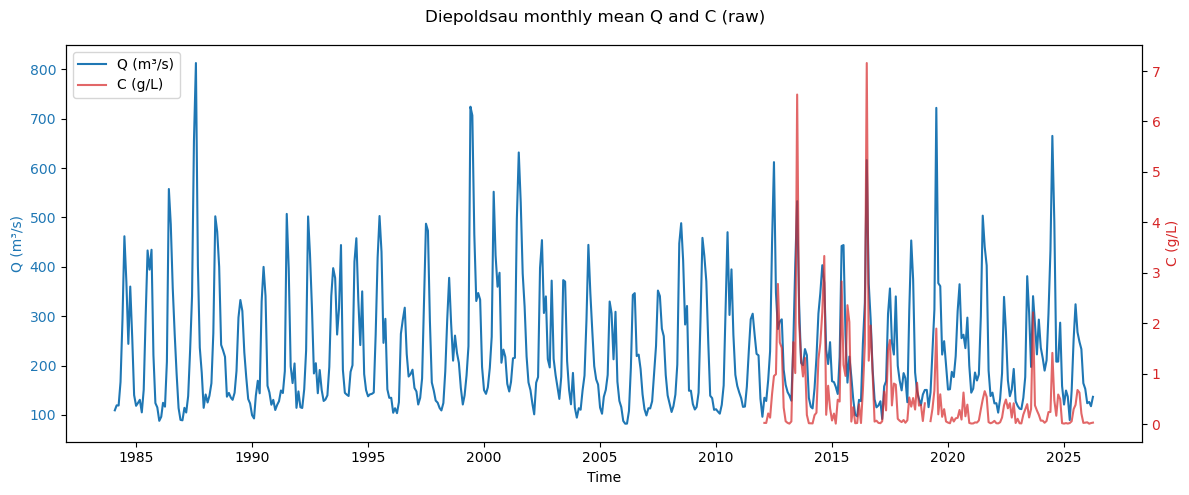

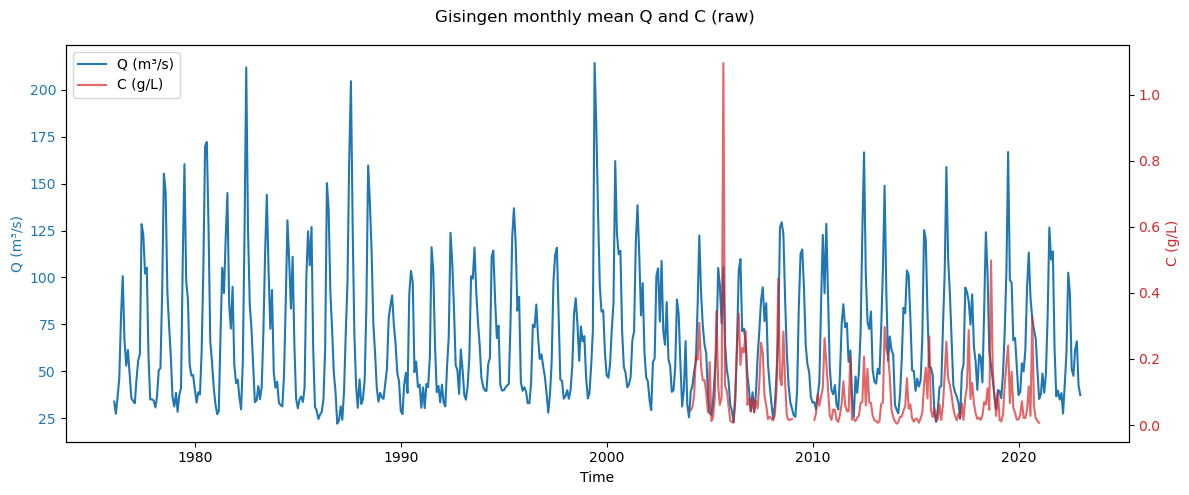

In [91]:
for station, dfQ, dfC in [('Diepoldsau', qD, sscD), ('Gisingen', qG, sscG)]:
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(dfQ.index, dfQ['q_m3s'], label='Q (m³/s)', color='tab:blue')
    ax.set_xlabel('Time'); ax.set_ylabel('Q (m³/s)', color='tab:blue')
    ax.tick_params(axis='y', labelcolor='tab:blue')
    ax2 = ax.twinx()
    ax2.plot(dfC.index, dfC.iloc[:, 0], label='C (g/L)', color='tab:red', alpha=0.7)
    ax2.set_ylabel('C (g/L)', color='tab:red')
    ax2.tick_params(axis='y', labelcolor='tab:red')
    lines  = ax.get_legend_handles_labels()
    lines2 = ax2.get_legend_handles_labels()
    ax.legend(lines[0]+lines2[0], lines[1]+lines2[1], loc='upper left')
    fig.suptitle(f'{station} monthly mean Q and C (raw)')
    fig.tight_layout(); plt.show()


## 1.1 Log transformation
Q and SSC are strictly positive and span several orders of magnitude.
Applying ln(x) before detrending and deseasonalising:
- removes positive skewness (log-normal assumption, standard in hydrology)
- stabilises variance across months
- ensures detrending and seasonal means are estimated on a symmetric series

Box-Cox λ ≈ 0 confirms the log is the appropriate transformation.


In [92]:
qD_log   = log_transform(qD,   'q_m3s')
qG_log   = log_transform(qG,   'q_m3s')
sscD_log = log_transform(sscD, sscD.columns[0])
sscG_log = log_transform(sscG, sscG.columns[0])

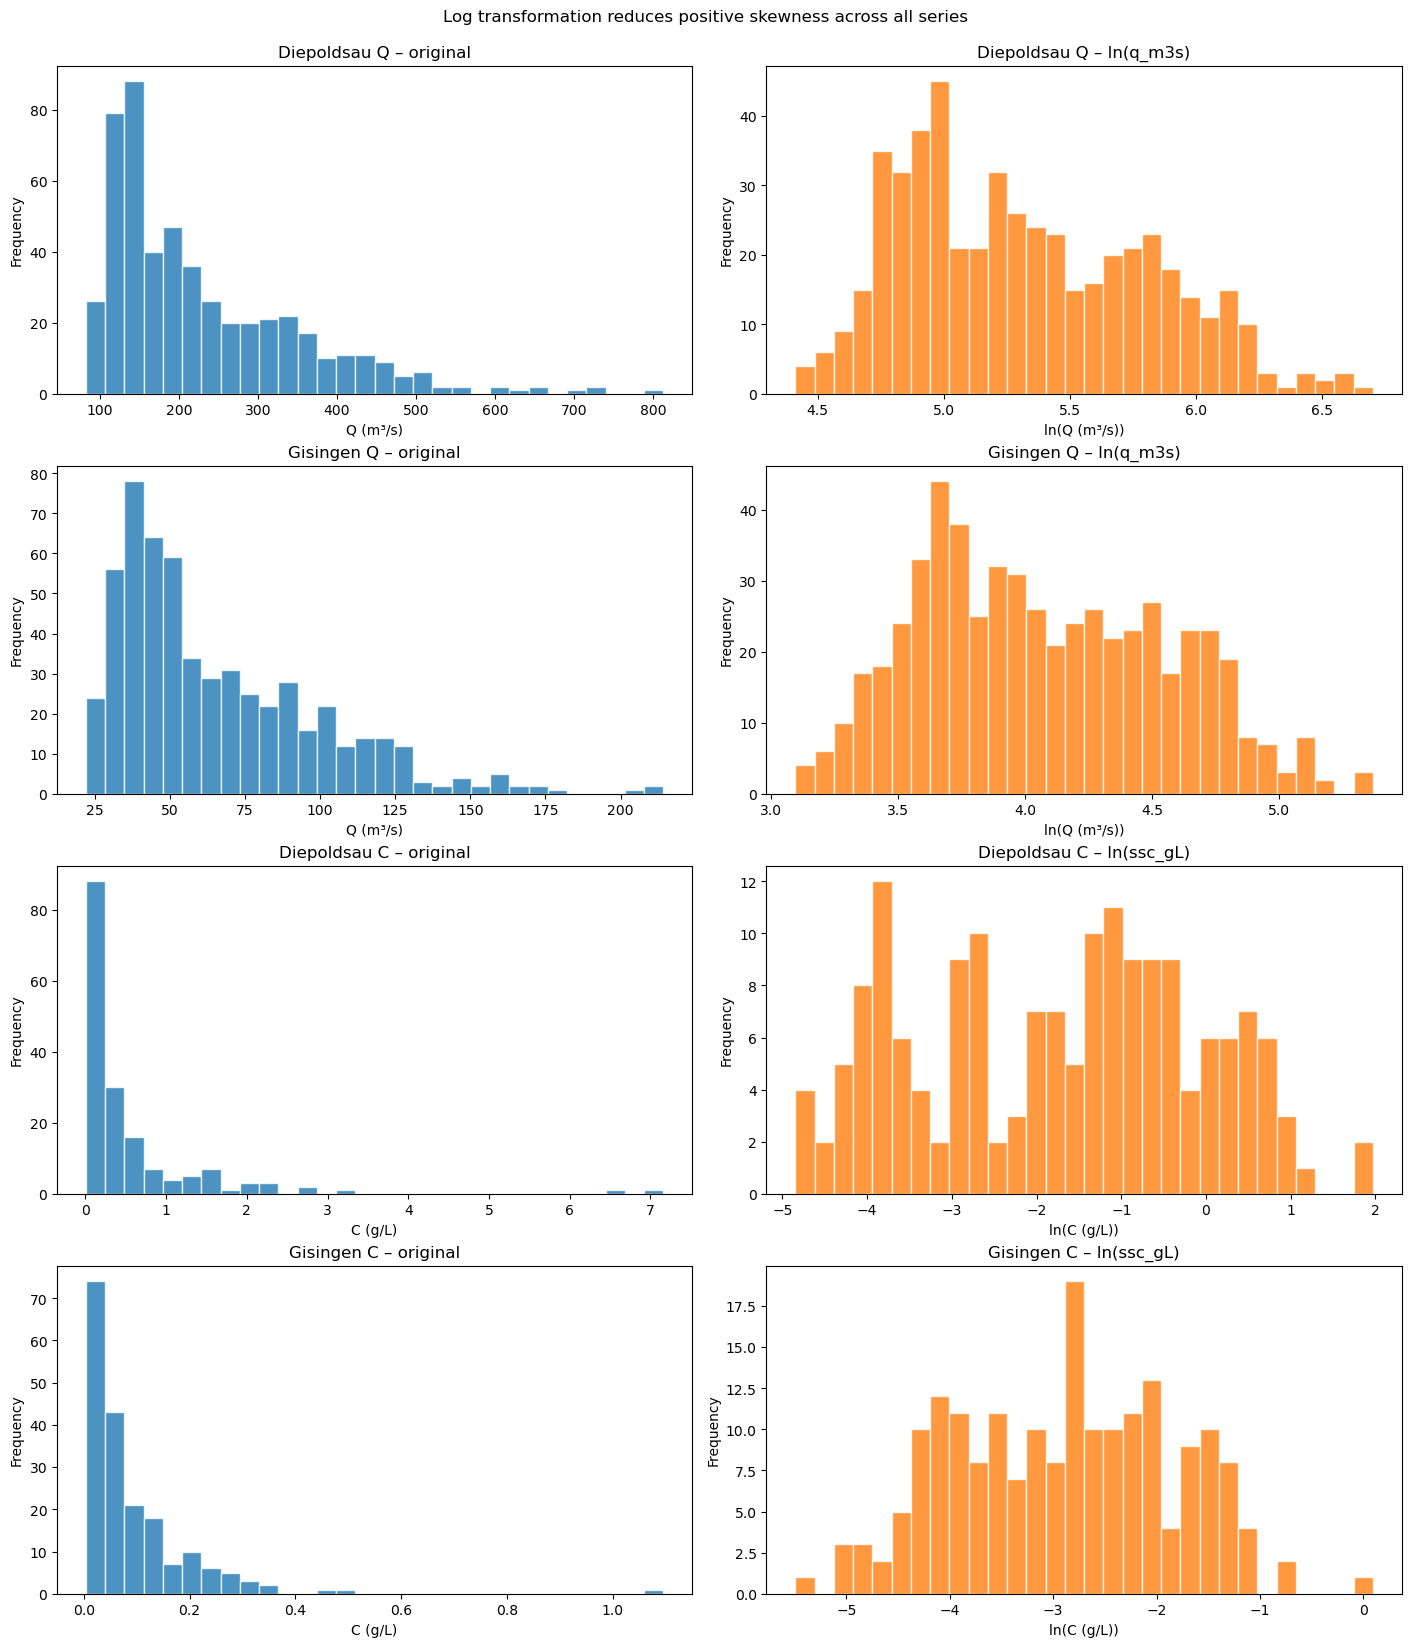

In [93]:
series_info = [
    ('Diepoldsau Q', qD_log, 'q_m3s', 'Q (m³/s)'),
    ('Gisingen Q', qG_log, 'q_m3s', 'Q (m³/s)'),
    ('Diepoldsau C', sscD_log, sscD_log.columns[0], 'C (g/L)'),
    ('Gisingen C', sscG_log, sscG_log.columns[0], 'C (g/L)'),
]

fig, axes = plt.subplots(4, 2, figsize=(14, 16), constrained_layout=True)
for i, (title, df, col, orig_label) in enumerate(series_info):
    raw = np.exp(df[col].dropna())
    axes[i, 0].hist(raw, bins=30, color='tab:blue', edgecolor='white', alpha=0.8)
    axes[i, 0].set_title(f'{title} – original')
    axes[i, 0].set_xlabel(orig_label)
    axes[i, 0].set_ylabel('Frequency')

    axes[i, 1].hist(df[col].dropna(), bins=30, color='tab:orange', edgecolor='white', alpha=0.8)
    axes[i, 1].set_title(f'{title} – ln({col})')
    axes[i, 1].set_xlabel(f'ln({orig_label})')
    axes[i, 1].set_ylabel('Frequency')

plt.suptitle('Log transformation reduces positive skewness across all series', y=1.02)
plt.show()


## 1.2 Stationarity test and trend removal
Linear trend test at 5 % significance on ln(Q) and ln(C).
A significant slope in log-space = exponential trend in original units.
If significant: subtract fitted linear trend.
If not: subtract global mean.


In [94]:
station_results  = []
transform_info = {}
detrended_series = {}

for station, dfQ, dfC in [('Diepoldsau', qD_log, sscD_log), ('Gisingen', qG_log, sscG_log)]:
    for var, df, col in [('Q', dfQ, 'q_m3s'), ('C', dfC, dfC.columns[0])]:
        key = f'{var}_{station}'
        # 1) Seasonal standardisation on ln(x)
        z, m_mean, m_std = seasonal_standardise(df[col].dropna())
        # 2) Test for trend and detrend the seasonally-standardised series
        det, res = test_and_detrend(z.to_frame(name=col), col)
        # store the detrended (seasonal-standardised then detrended) series
        detrended_series[key] = det.squeeze()
        transform_info[key] = {
            'month_mean': m_mean,
            'month_std': m_std,
            'detrend': res,
        }
        station_results.append({'station': station, 'variable': var, **res})

,0,1,2,3
station,Diepoldsau,Diepoldsau,Gisingen,Gisingen
variable,Q,C,Q,C
n_points,507,169,564,192
intercept,-0.079758,0.766175,-0.017708,0.487706
slope,0.000315,-0.009121,0.000063,-0.005107
pvalue,0.293997,0.0,0.806211,0.000039
significant,False,True,False,True
detrend_method,mean,linear trend,mean,linear trend
mean_after_detrend,0.0,0.0,0.0,0.0
variance_after_detrend,0.978261,0.735341,0.980462,0.861873


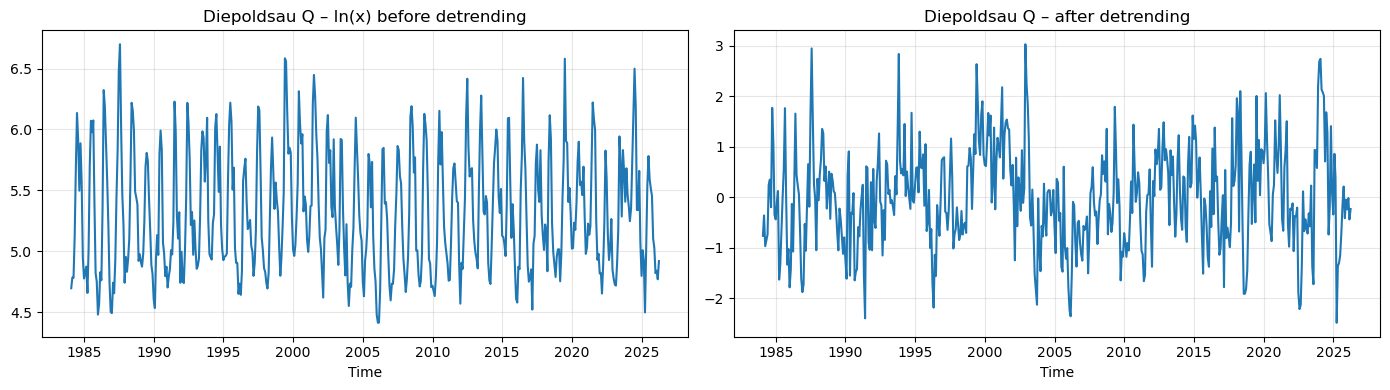

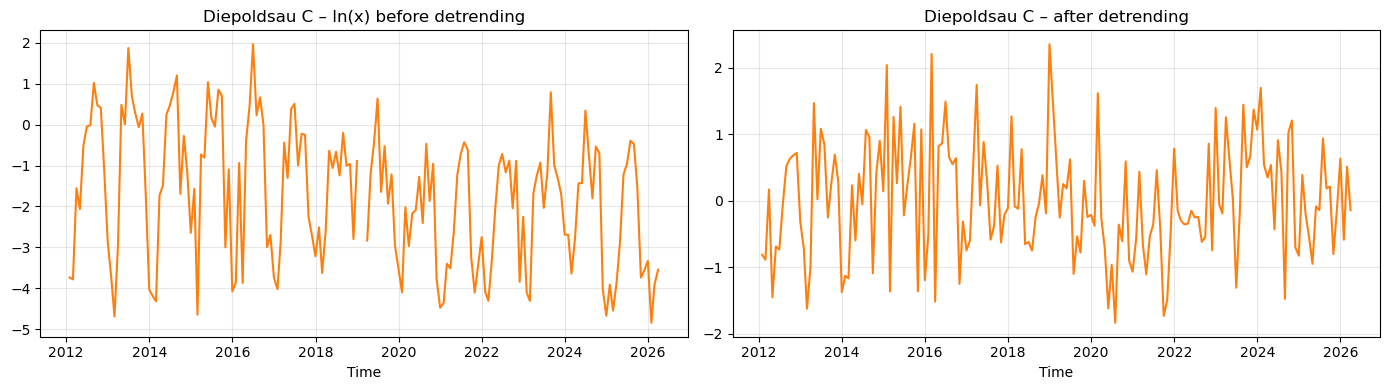

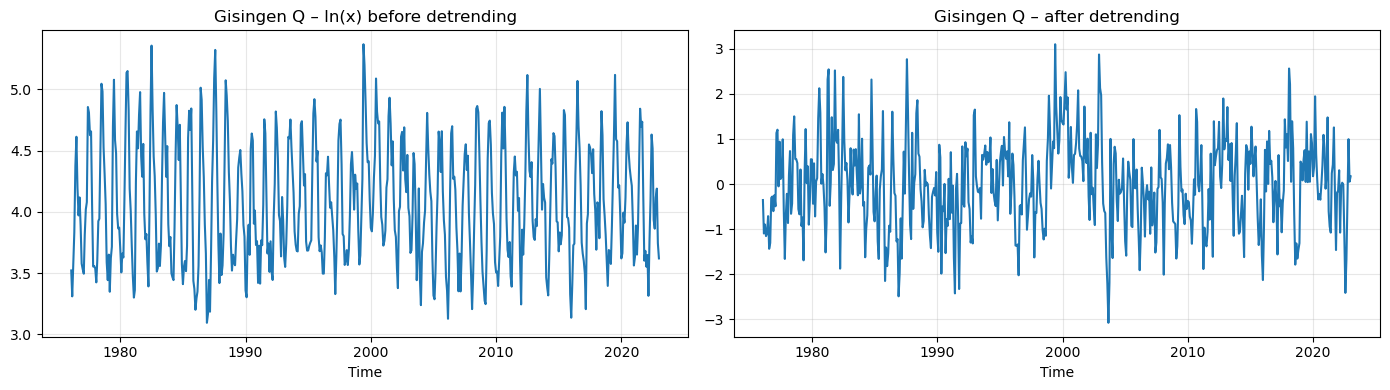

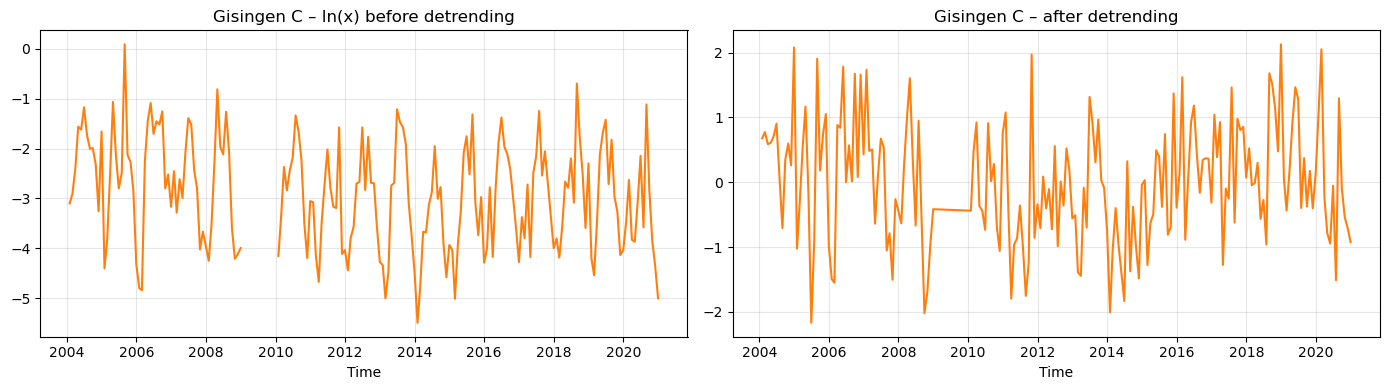

In [95]:
display(pd.DataFrame(station_results).T)

# Plot original vs detrended for each series
for station in ['Diepoldsau', 'Gisingen']:
    for var in ['Q', 'C']:
        key = f'{var}_{station}'
        det = detrended_series[key]
        orig_map = {
            ('Diepoldsau', 'Q'): qD_log,
            ('Gisingen', 'Q'): qG_log,
            ('Diepoldsau', 'C'): sscD_log,
            ('Gisingen', 'C'): sscG_log,
        }
        original = orig_map[(station, var)]
        col = 'q_m3s' if var == 'Q' else original.columns[0]
        color = 'tab:blue' if var == 'Q' else 'tab:orange'
        fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 4))
        a1.plot(original.index, original[col], color=color)
        a1.set_title(f'{station} {var} – ln(x) before detrending')
        a2.plot(det.index, det, color=color)
        a2.set_title(f'{station} {var} – after detrending')
        for a in [a1, a2]:
            a.set_xlabel('Time'); a.grid(alpha=0.3)
        plt.tight_layout(); plt.show()



## 2. Seasonal standardisation and ACF / PACF

After log-transform and detrending the series still has a 12-month seasonal
cycle. We remove it via seasonal standardisation (Method 1, §6.5.3):

    z_t = (ln(x_t) − mean_month) / std_month

For SSC series (C) the professor flagged data gaps:
- Diepoldsau 2019 → split series, compute ACF/PACF on each segment, average
- Gisingen   2009 → same

We report the Pearson r between the two segment ACFs to check whether
the autocorrelation structure changed across the gap.



=== Diepoldsau Q ===
  Checking for data gaps...
  No significant gap found, using full series.


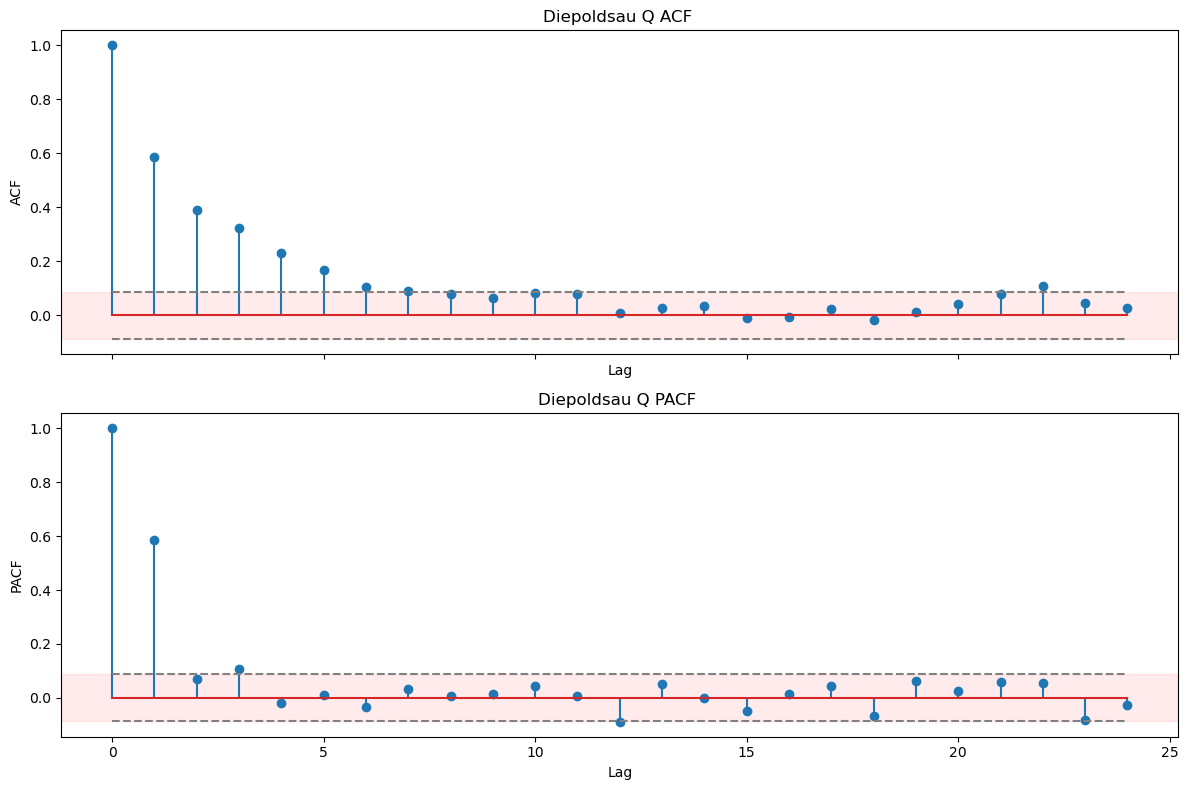


=== Diepoldsau C ===
  Checking for data gaps...
  Using gap at 2019-01-31 for ACF/PACF splitting.


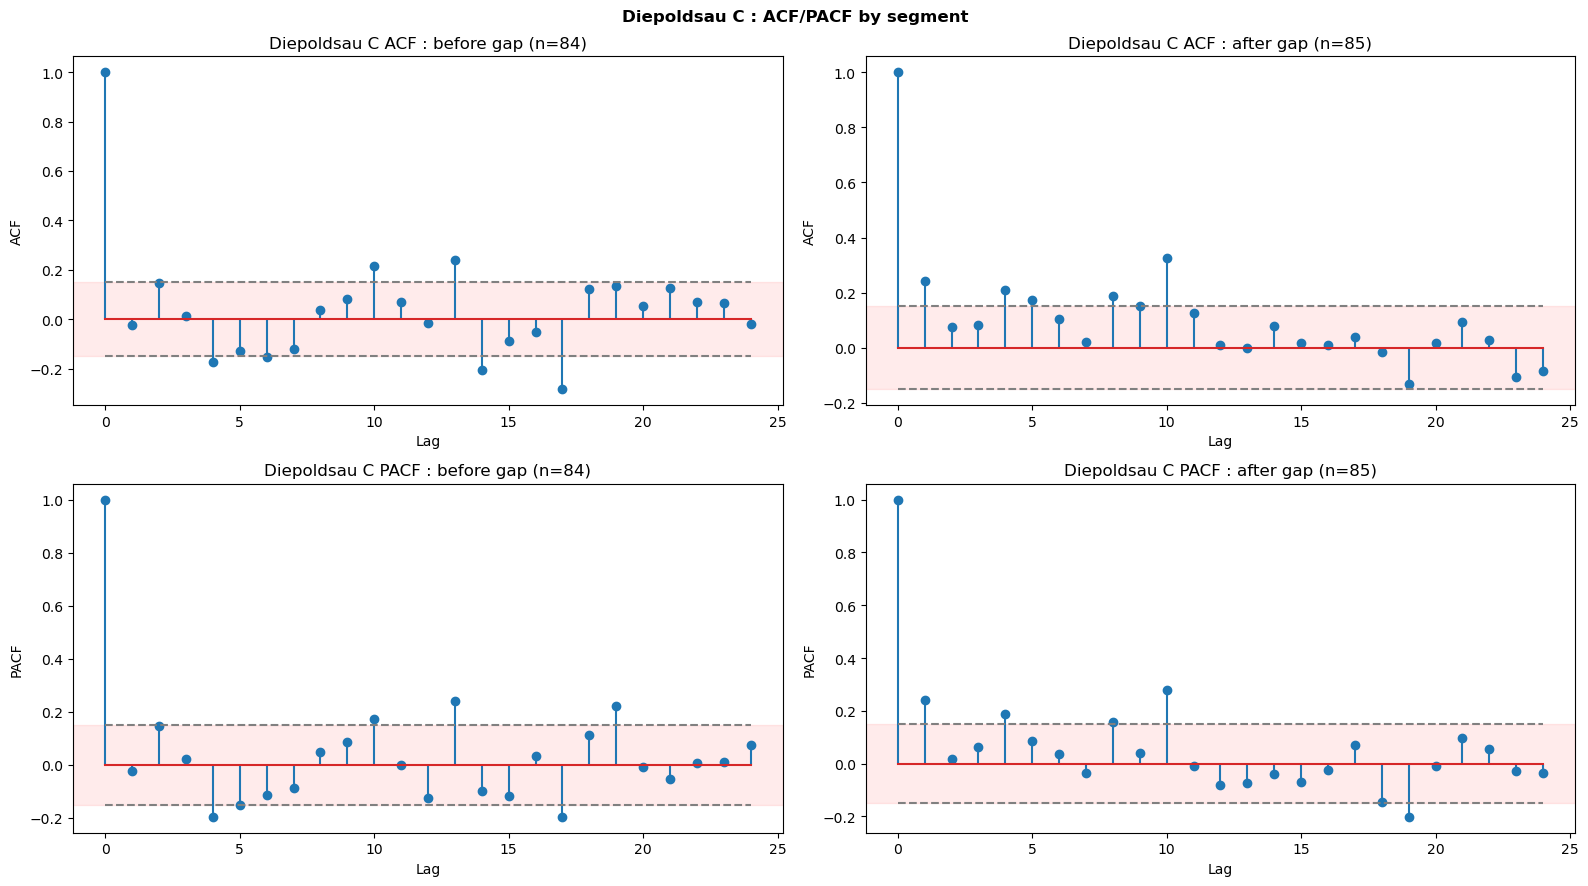

    Pearson r between segment ACFs: -0.059 (different : worth discussing in report)


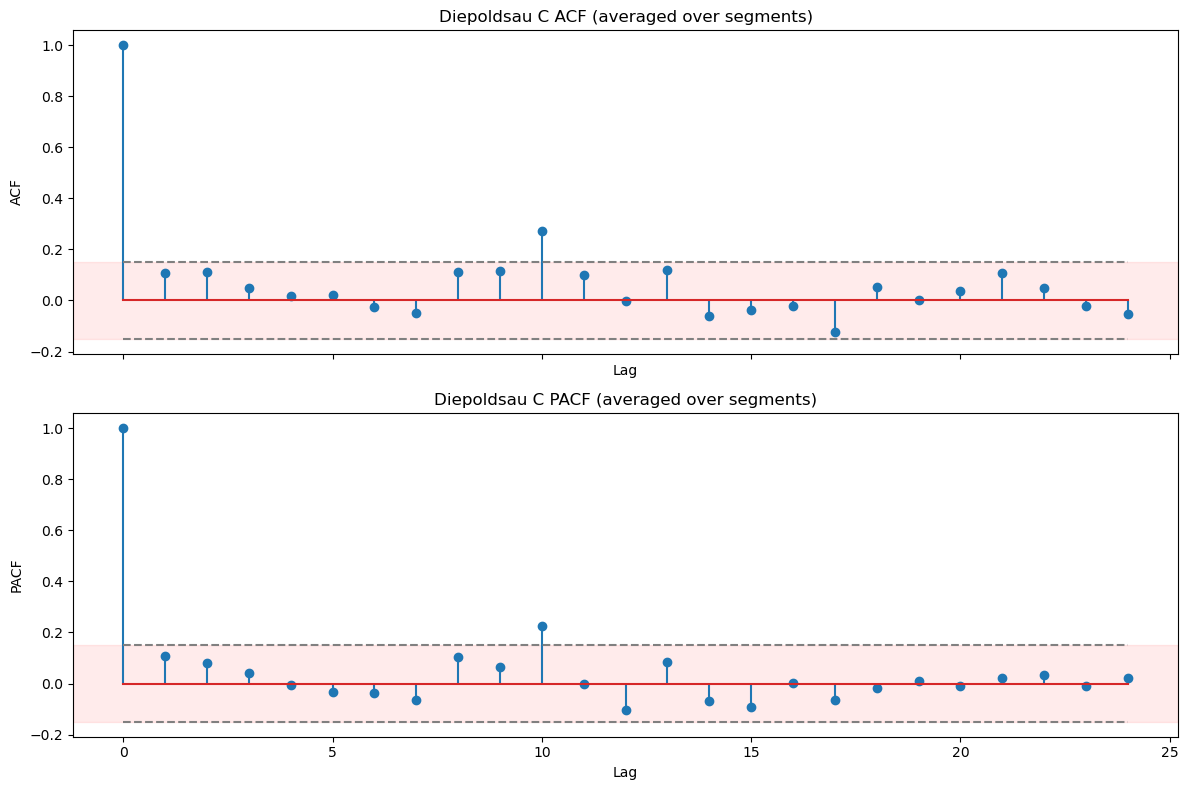


=== Gisingen Q ===
  Checking for data gaps...
  No significant gap found, using full series.


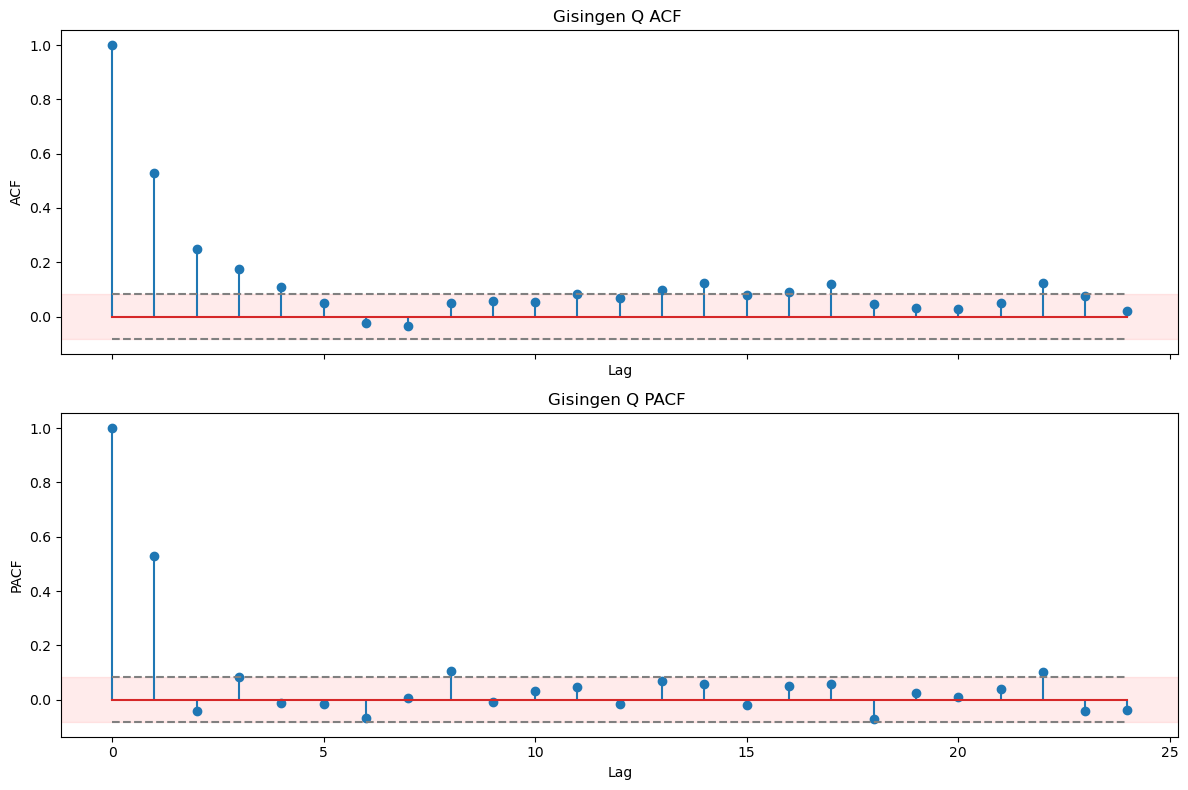


=== Gisingen C ===
  Checking for data gaps...
  Using gap at 2009-01-31 for ACF/PACF splitting.


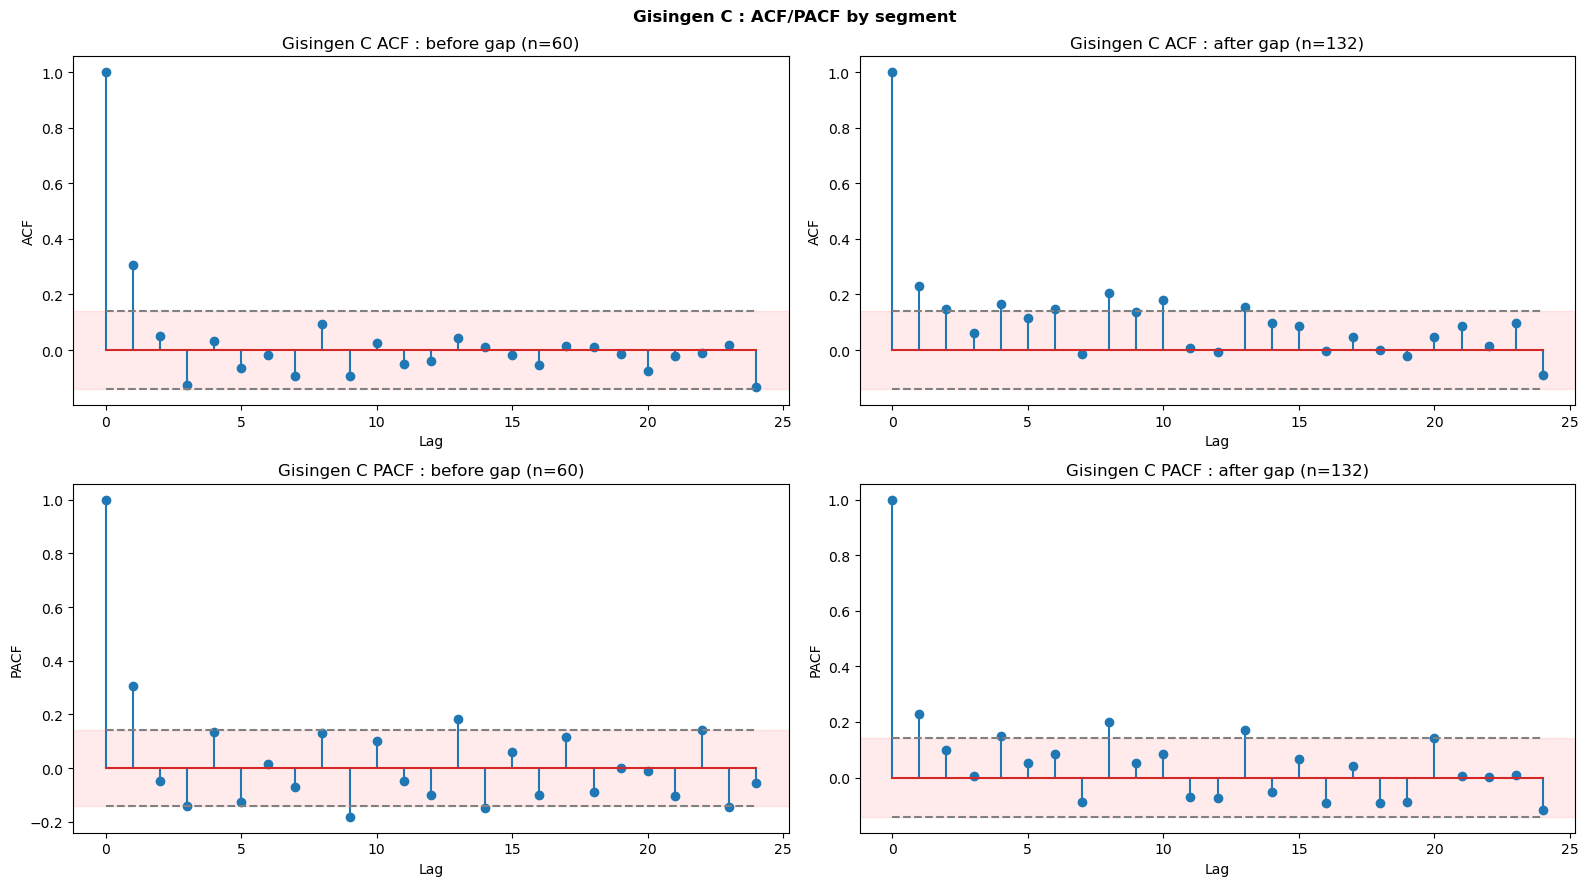

    Pearson r between segment ACFs: 0.657 (different : worth discussing in report)


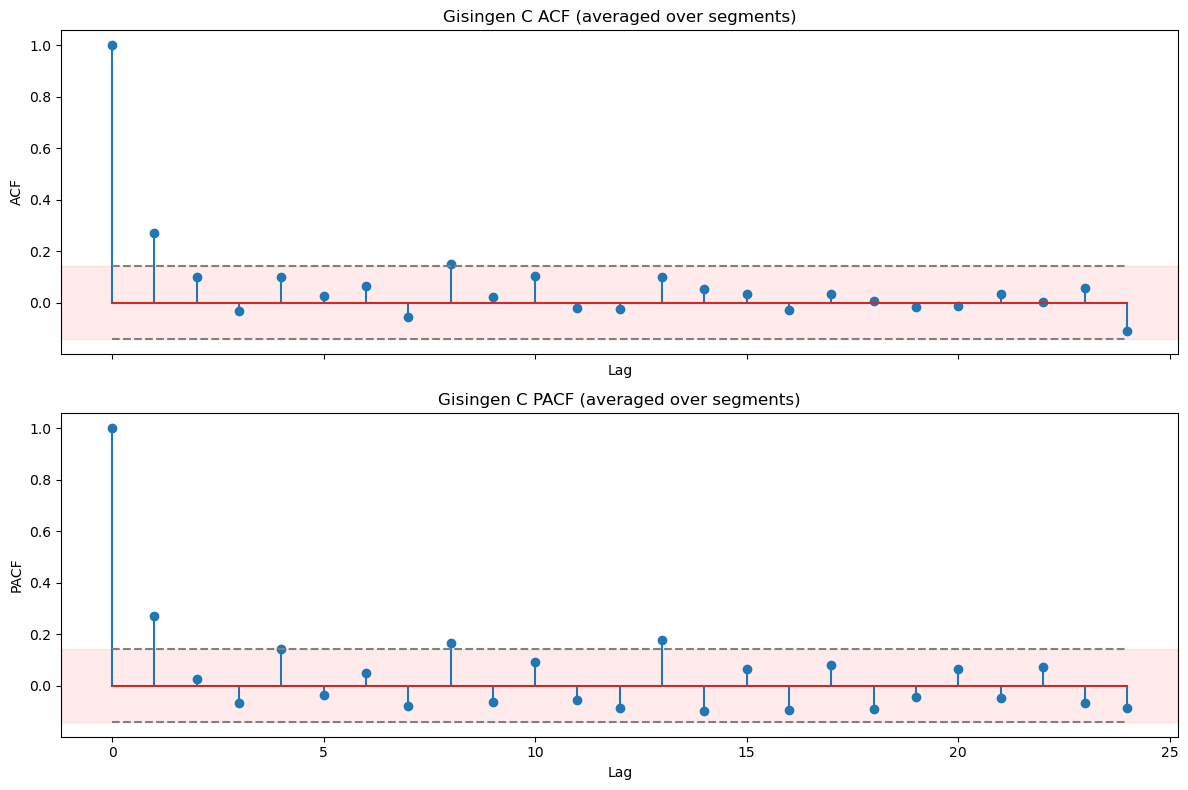

In [96]:
max_lag  = 24
z_series = {}

for key, raw_series in detrended_series.items():
    variable, station = key.split('_', 1)
    print(f'\n=== {station} {variable} ===')

    # The series in `detrended_series` is already seasonally-standardised then detrended.
    z = raw_series.dropna()
    z_series[key] = z

    # Auto-detect gaps from the raw series
    print(f'  Checking for data gaps...')
    gap_date = gap_dates.get(key)
    if gap_date is None:
        print(f'  No significant gap found, using full series.')
    else:
        print(f'  Using gap at {gap_date.date()} for ACF/PACF splitting.')

    acf_avg, pacf_avg, conf, segments = gap_aware_acf_pacf(
        z, max_lag, gap_date)
    plot_acf_pacf(station, variable, acf_avg, pacf_avg, conf, segments, max_lag)

## 2.2 AR and ARMA model fitting

Fit on the fully pre-processed z_series (log + detrended + deseasonalised).

Model selection:
- Scan AR(1..max_ar) and ARMA(1..max_ar, 1..3), ranked by BIC.
- Default max_ar = 4. Q Gisingen uses max_ar = 6 because its residuals
  showed long-lag autocorrelation at lag 24 with a lower-order model.
- All orders well within the professor's cap of 12.


In [97]:
for key, raw_series in detrended_series.items():
    variable, station = key.split('_', 1)
    print(f'\n=== {station} {variable} ===')

    # The series is already seasonally-standardised then detrended.
    z = raw_series.dropna()

    # Check monthly frequency
    try:
        z = ensure_monthly_freq(z)
        print(f'  Monthly frequency: OK')
    except Exception as e:
        print(f'  Monthly frequency: WARNING – {e}')

    z_series[key] = z
    ...


=== Diepoldsau Q ===
  Monthly frequency: WARNING – name 'ensure_monthly_freq' is not defined

=== Diepoldsau C ===
  Monthly frequency: WARNING – name 'ensure_monthly_freq' is not defined

=== Gisingen Q ===
  Monthly frequency: WARNING – name 'ensure_monthly_freq' is not defined

=== Gisingen C ===
  Monthly frequency: WARNING – name 'ensure_monthly_freq' is not defined


In [98]:
fitted_models = fit_best_models(z_series)



===== Diepoldsau Q =====


c:\Users\leoni\miniconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\leoni\miniconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\leoni\miniconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\leoni\miniconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\leoni\miniconda3\Lib\site-packages\statsmodels\base\

,model,p,q,bic
0,AR,1,0,1233.020842
6,ARMA,1,1,1235.349188
1,AR,2,0,1236.627653
2,AR,3,0,1236.911328
7,ARMA,1,2,1238.270821
9,ARMA,2,1,1239.805842
10,ARMA,2,2,1242.224999
8,ARMA,1,3,1242.655762
12,ARMA,3,1,1242.891595
3,AR,4,0,1242.972837


  → Best AR:   AR(1)  BIC=1233.0
  → Best ARMA: ARMA(1,1)  BIC=1235.3

===== Diepoldsau C =====


c:\Users\leoni\miniconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\leoni\miniconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\leoni\miniconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\leoni\miniconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\leoni\miniconda3\Lib\site-packages\statsmodels\base\

...

  → Best AR:   AR(1)  BIC=1423.8
  → Best ARMA: ARMA(1,1)  BIC=1428.7

===== Gisingen C =====


c:\Users\leoni\miniconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\leoni\miniconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\leoni\miniconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\leoni\miniconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\leoni\miniconda3\Lib\site-packages\statsmodels\base\

,model,p,q,bic
0,AR,1,0,516.897560
10,ARMA,2,2,518.220233
7,ARMA,1,2,520.805994
1,AR,2,0,521.545385
6,ARMA,1,1,521.641586
9,ARMA,2,1,522.076980
8,ARMA,1,3,526.059783
2,AR,3,0,526.397745
12,ARMA,3,1,526.738070
3,AR,4,0,527.872156


c:\Users\leoni\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\leoni\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\leoni\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\leoni\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dat

  → Best AR:   AR(1)  BIC=516.9
  → Best ARMA: ARMA(2,2)  BIC=518.2


## 3. Model evaluation

For each fitted model:
- (a) Empirical vs theoretical ACF (using ArmaProcess with fitted params)
- (b) Residual ACF — all lags should be within the 95% CI
- (c) Probability plot (visual normality check)



===== Diepoldsau Q Evaluation =====


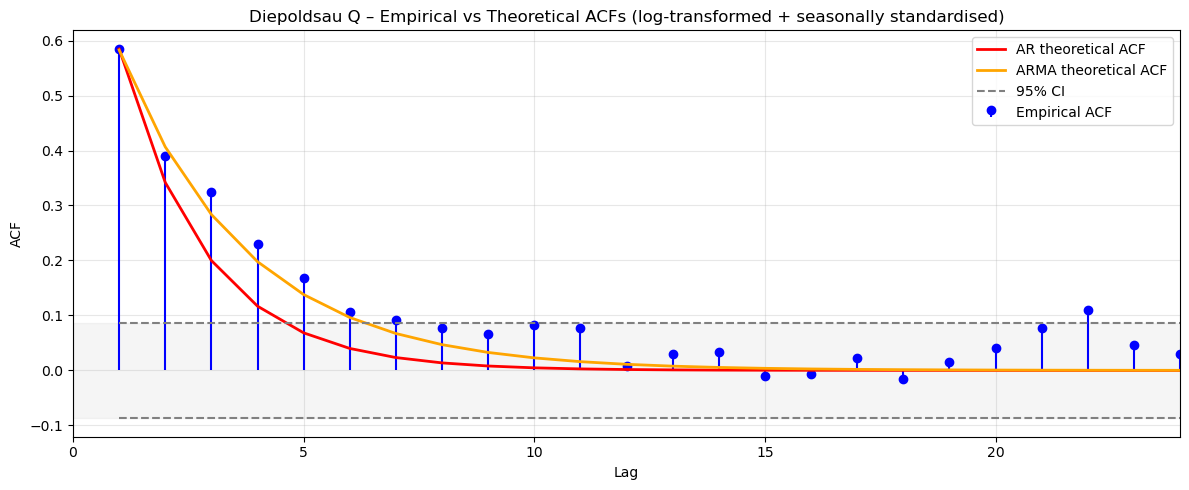

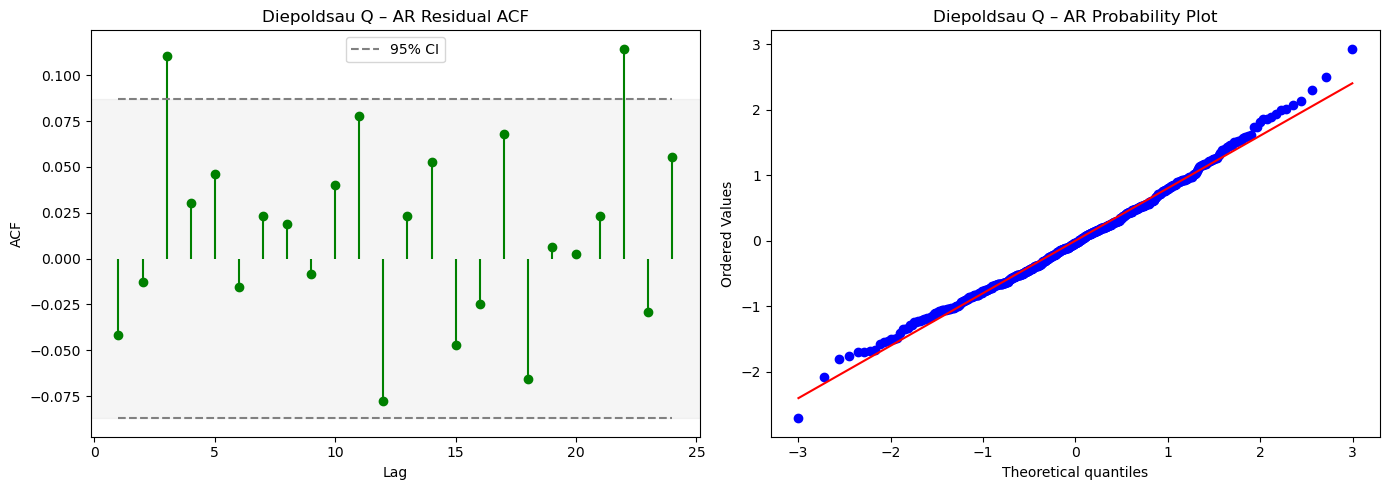

  AR residual ACF significant at lags: [3, 22]


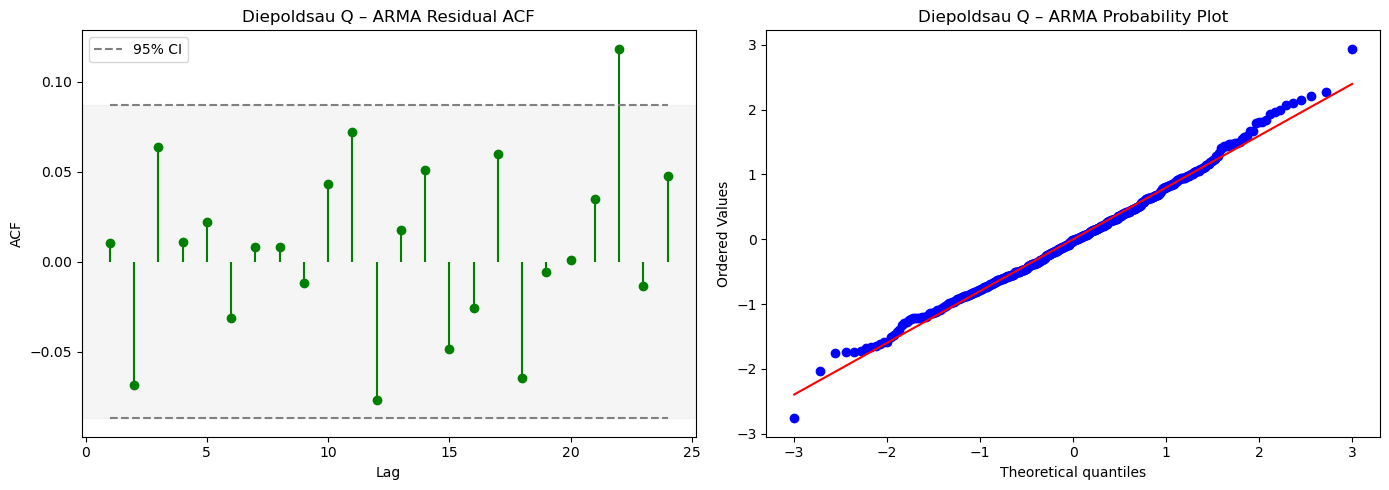

  ARMA residual ACF significant at lags: [22]

===== Diepoldsau C Evaluation =====


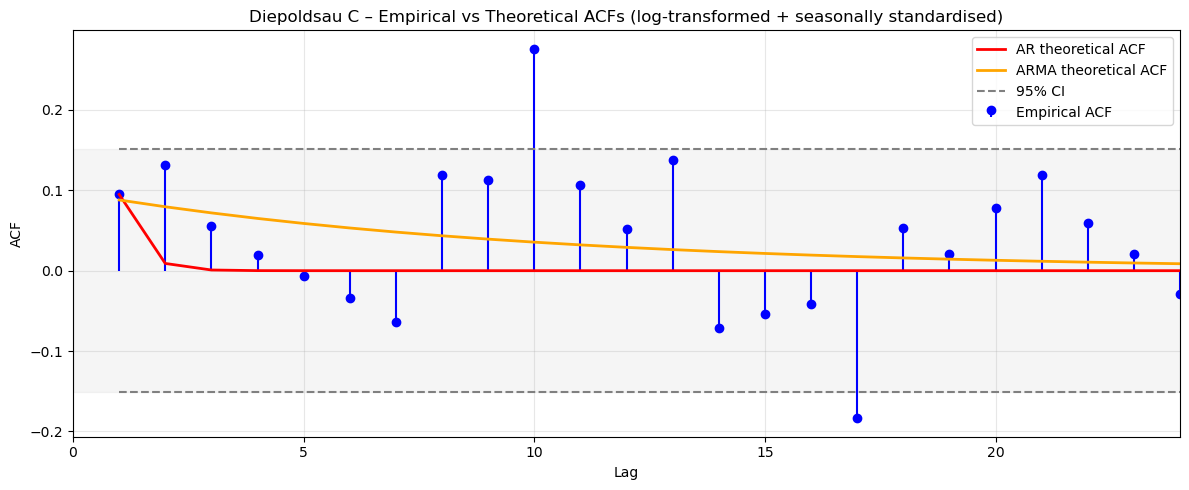

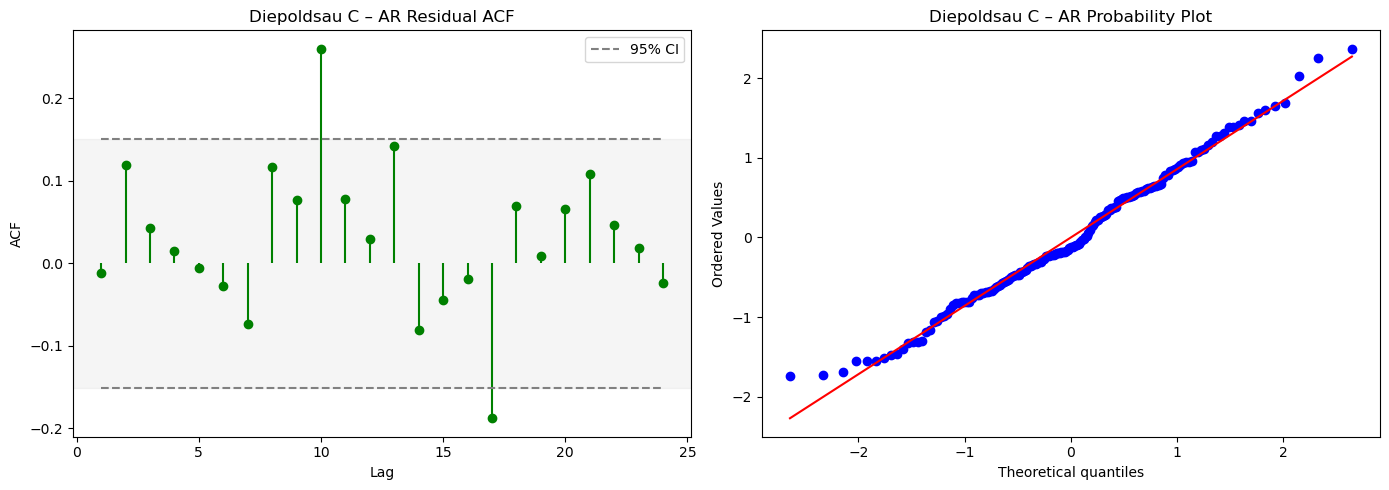

  AR residual ACF significant at lags: [10, 17]


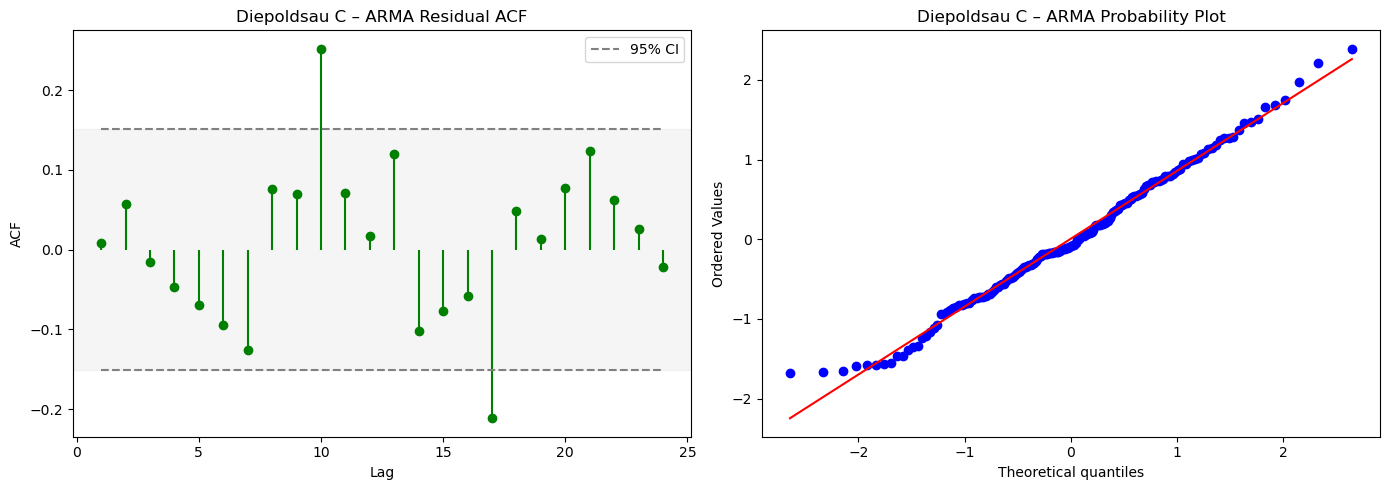

  ARMA residual ACF significant at lags: [10, 17]

===== Gisingen Q Evaluation =====


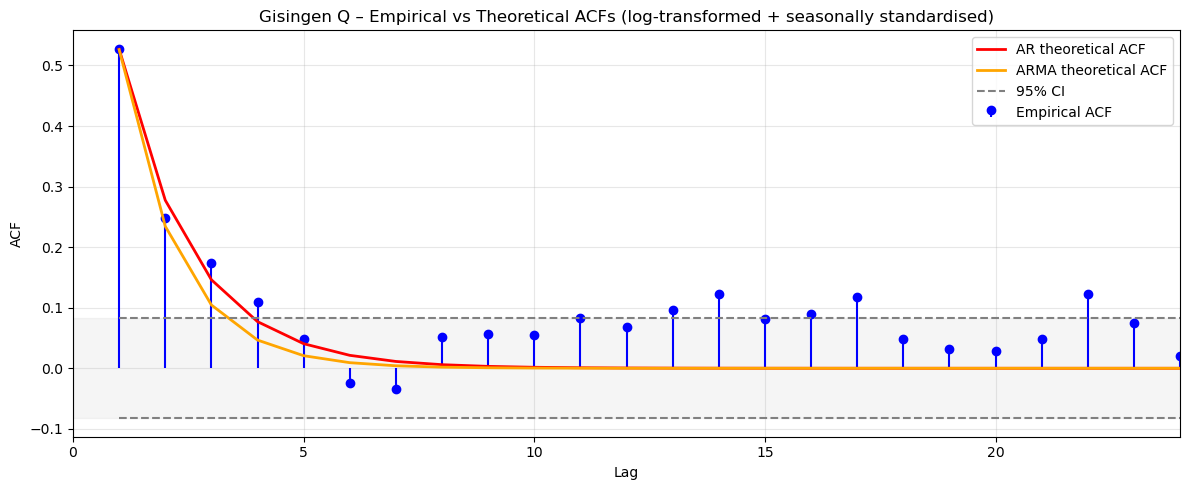

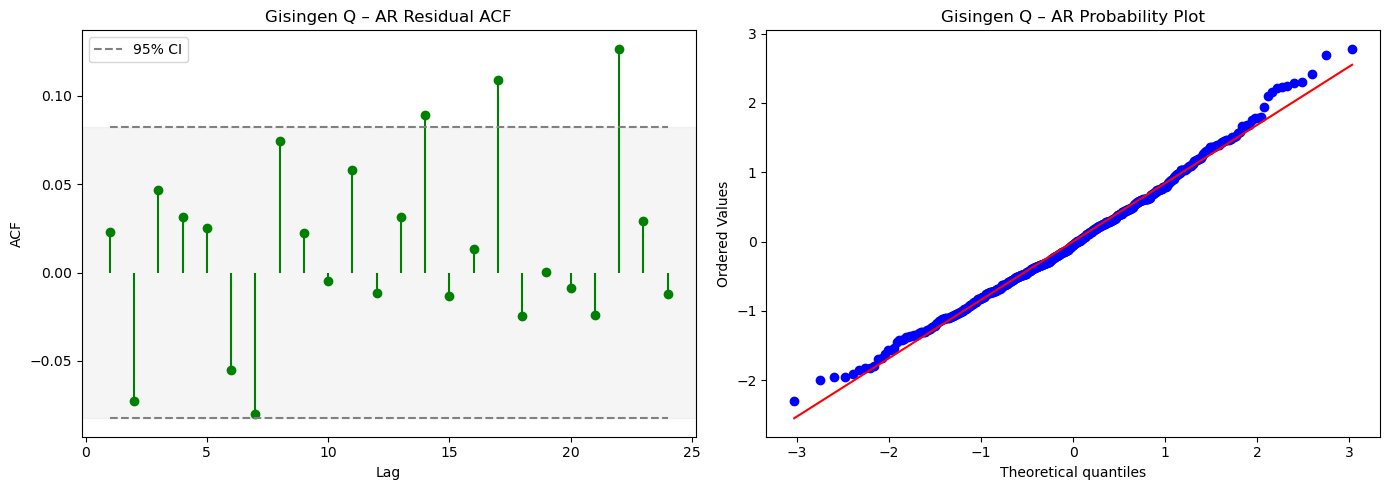

  AR residual ACF significant at lags: [14, 17, 22]


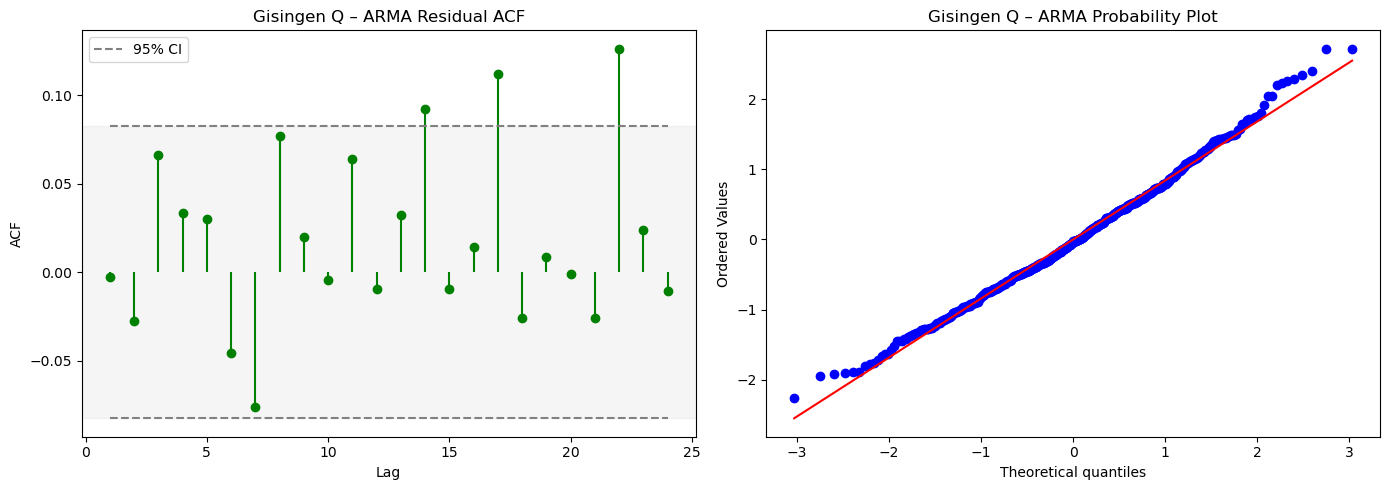

  ARMA residual ACF significant at lags: [14, 17, 22]

===== Gisingen C Evaluation =====


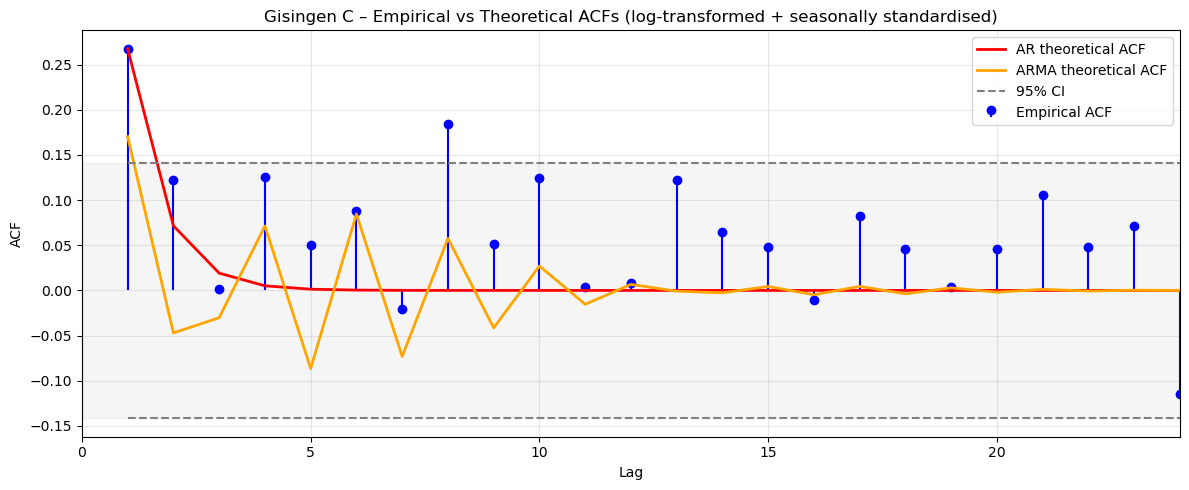

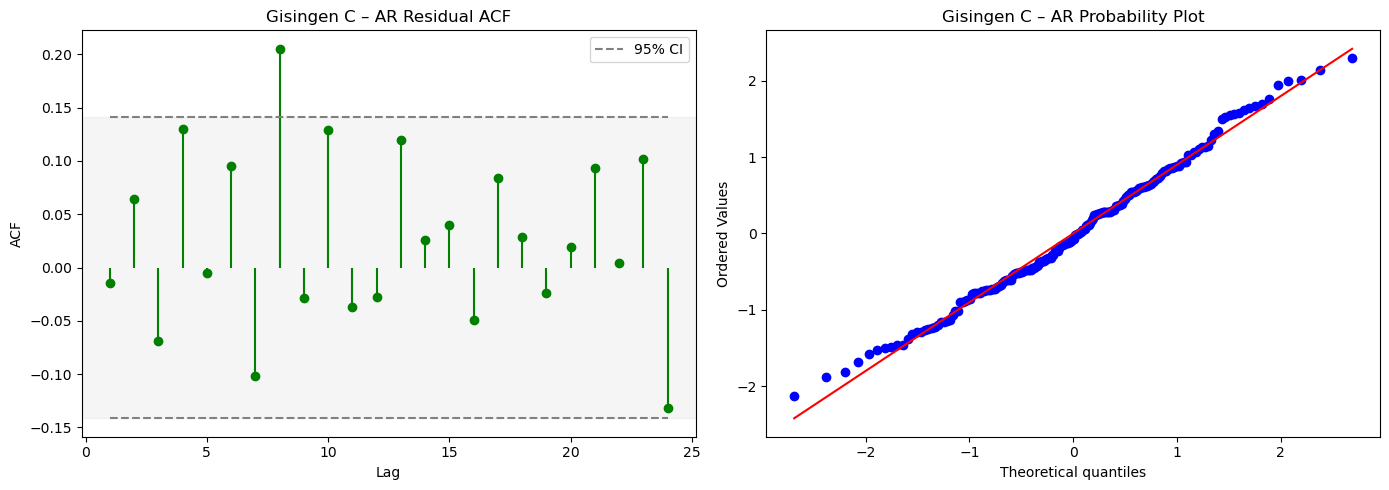

  AR residual ACF significant at lags: [8]


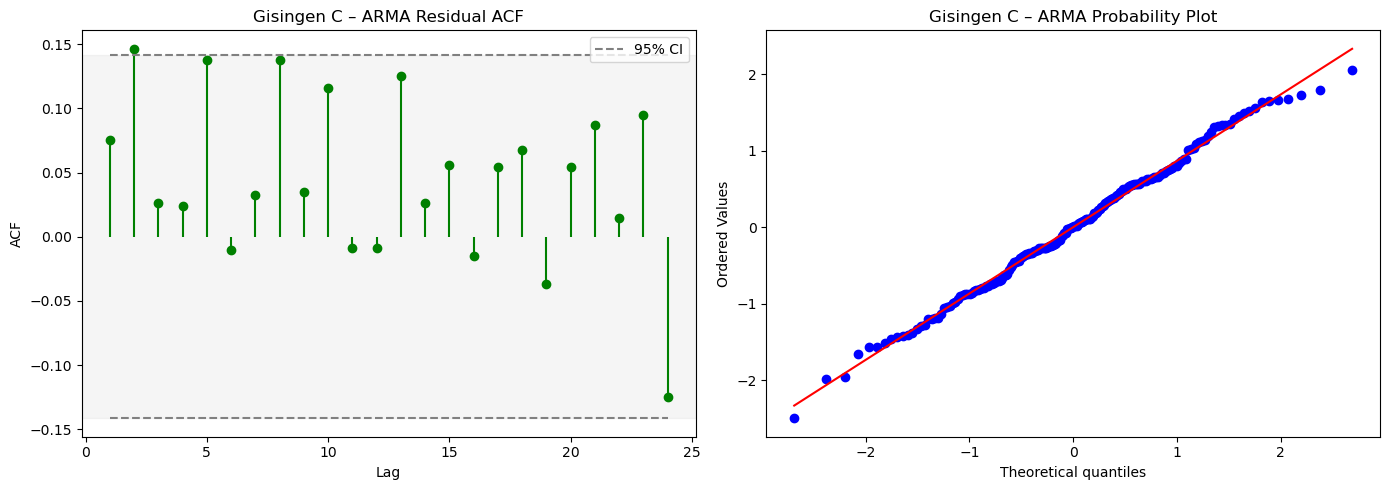

  ARMA residual ACF significant at lags: [2]


In [99]:
evaluate_all_models(z_series, fitted_models, max_lag=24)


## 3.1 PPCC normality test (Shapiro-Wilk)


In [100]:
ppcc_results = ppcc_test(fitted_models, alpha=0.05)
display(ppcc_results)


PPCC / SHAPIRO-WILK NORMALITY TEST
Decision alpha = 0.05
Note: at n>300 the test is very sensitive – inspect QQ plots.
Q_Diepoldsau_AR: PPCC=0.9964  Shapiro-p=0.0297  normal=NO ✗  n=507
Q_Diepoldsau_ARMA: PPCC=0.9965  Shapiro-p=0.0424  normal=NO ✗  n=507
C_Diepoldsau_AR: PPCC=0.9955  Shapiro-p=0.2008  normal=YES ✓  n=169
C_Diepoldsau_ARMA: PPCC=0.9962  Shapiro-p=0.2962  normal=YES ✓  n=169
Q_Gisingen_AR: PPCC=0.9970  Shapiro-p=0.0211  normal=NO ✗  n=564
Q_Gisingen_ARMA: PPCC=0.9971  Shapiro-p=0.0219  normal=NO ✗  n=564
C_Gisingen_AR: PPCC=0.9965  Shapiro-p=0.2860  normal=YES ✓  n=192
C_Gisingen_ARMA: PPCC=0.9978  Shapiro-p=0.6846  normal=YES ✓  n=192


,model,ppcc,sw_p,normal,n
0,Q_Diepoldsau_AR,0.996359,0.029732,False,507
1,Q_Diepoldsau_ARMA,0.996549,0.042405,False,507
2,C_Diepoldsau_AR,0.995490,0.200807,True,169
3,C_Diepoldsau_ARMA,0.996225,0.296182,True,169
4,Q_Gisingen_AR,0.997010,0.021052,False,564
5,Q_Gisingen_ARMA,0.997089,0.021896,False,564
6,C_Gisingen_AR,0.996528,0.285983,True,192
7,C_Gisingen_ARMA,0.997759,0.684601,True,192


## 3.2 PPCC critical-value test (Monte Carlo)


In [101]:
ppcc_mc_results = ppcc_critical_test(fitted_models, alpha=0.05, n_sims=2000)
display(ppcc_mc_results)


PPCC CRITICAL-VALUE TEST (alpha=0.05, sims=2000)
Q_Diepoldsau_AR: r=0.9964  r_crit=0.9993  reject (not normal) ✗  n=507
Q_Diepoldsau_ARMA: r=0.9965  r_crit=0.9993  reject (not normal) ✗  n=507
C_Diepoldsau_AR: r=0.9955  r_crit=0.9984  reject (not normal) ✗  n=169
C_Diepoldsau_ARMA: r=0.9962  r_crit=0.9984  reject (not normal) ✗  n=169
Q_Gisingen_AR: r=0.9970  r_crit=0.9994  reject (not normal) ✗  n=564
Q_Gisingen_ARMA: r=0.9971  r_crit=0.9994  reject (not normal) ✗  n=564
C_Gisingen_AR: r=0.9965  r_crit=0.9985  reject (not normal) ✗  n=192
C_Gisingen_ARMA: r=0.9978  r_crit=0.9985  reject (not normal) ✗  n=192


,model,r,r_crit,accept,n
0,Q_Diepoldsau_AR,0.996359,0.999322,False,507
1,Q_Diepoldsau_ARMA,0.996549,0.999322,False,507
2,C_Diepoldsau_AR,0.995490,0.998381,False,169
3,C_Diepoldsau_ARMA,0.996225,0.998381,False,169
4,Q_Gisingen_AR,0.997010,0.999382,False,564
5,Q_Gisingen_ARMA,0.997089,0.999382,False,564
6,C_Gisingen_AR,0.996528,0.998488,False,192
7,C_Gisingen_ARMA,0.997759,0.998488,False,192


## 3.3 Portmanteau (Ljung-Box) independence test

**Improvement:** lags [6, 12] only.
Lag 24 was removed because for monthly series with n>300 it detects
trivially small long-range dependencies that are statistically significant
but practically irrelevant. Standard recommendation: h = min(10, n/5).


In [102]:
lb_results = ljungbox_test(fitted_models, lags=[6, 12], alpha=0.05)
display(lb_results)


PORTMANTEAU (LJUNG-BOX) TEST   alpha=0.05   lags=[6, 12]
Improvement: lag 24 removed – too strict for n>300 monthly data.
Q_Diepoldsau_AR: n=507  →  lag6: p=0.1798  lag12: p=0.1669  →  independent ✓
Q_Diepoldsau_ARMA: n=507  →  lag6: p=0.4994  lag12: p=0.4251  →  independent ✓
C_Diepoldsau_AR: n=169  →  lag6: p=0.8116  lag12: p=0.0508  →  independent ✓
C_Diepoldsau_ARMA: n=169  →  lag6: p=0.7540  lag12: p=0.0558  →  independent ✓
Q_Gisingen_AR: n=564  →  lag6: p=0.3031  lag12: p=0.1736  →  independent ✓
Q_Gisingen_ARMA: n=564  →  lag6: p=0.5067  lag12: p=0.2609  →  independent ✓
C_Gisingen_AR: n=192  →  lag6: p=0.3268  lag12: p=0.0423  →  NOT independent ✗
C_Gisingen_ARMA: n=192  →  lag6: p=0.1549  lag12: p=0.1732  →  independent ✓


,model,n,overall_independent,p_lag_6,indep_lag_6,p_lag_12,indep_lag_12
0,Q_Diepoldsau_AR,507,True,0.179776,True,0.166948,True
1,Q_Diepoldsau_ARMA,507,True,0.499412,True,0.425148,True
2,C_Diepoldsau_AR,169,True,0.811578,True,0.050822,True
3,C_Diepoldsau_ARMA,169,True,0.753994,True,0.055773,True
4,Q_Gisingen_AR,564,True,0.303147,True,0.173612,True
5,Q_Gisingen_ARMA,564,True,0.506715,True,0.260879,True
6,C_Gisingen_AR,192,False,0.326825,True,0.042254,False
7,C_Gisingen_ARMA,192,True,0.154915,True,0.173198,True


Q_Diepoldsau_AR: generated 120 months × 10 realizations
Q_Diepoldsau_ARMA: generated 120 months × 10 realizations
C_Diepoldsau_AR: generated 120 months × 10 realizations
C_Diepoldsau_ARMA: generated 120 months × 10 realizations
Q_Gisingen_AR: generated 120 months × 10 realizations
Q_Gisingen_ARMA: generated 120 months × 10 realizations
C_Gisingen_AR: generated 120 months × 10 realizations
C_Gisingen_ARMA: generated 120 months × 10 realizations

Best models for yield reconstruction:
  Q_Diepoldsau: Q_Diepoldsau_AR
  C_Diepoldsau: C_Diepoldsau_AR
  Q_Gisingen: Q_Gisingen_AR
  C_Gisingen: C_Gisingen_AR

=== Diepoldsau sediment mass yields ===


,historical_monthly,synthetic_monthly
1,6.386613,1.435870
2,7.922576,1.024513
3,21.669460,3.824902
4,86.194546,21.699622
5,302.499602,100.916243
6,949.525567,169.796756
7,260.928739,77.741889
8,364.973568,114.612908
9,144.419460,37.019687
10,104.572681,15.676607


,historical_yearly,synthetic_yearly
1984-12-31,NaN,NaN
1985-12-31,NaN,NaN
1986-12-31,NaN,NaN
1987-12-31,NaN,NaN
1988-12-31,NaN,NaN
1989-12-31,NaN,NaN
1990-12-31,NaN,NaN
1991-12-31,NaN,NaN
1992-12-31,NaN,NaN
1993-12-31,NaN,NaN


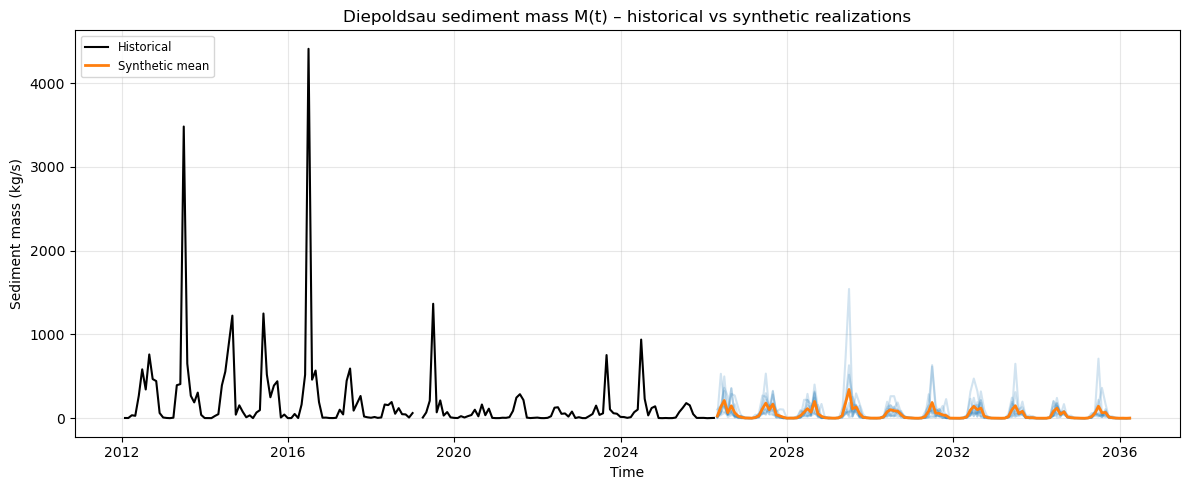


=== Gisingen sediment mass yields ===


,historical_monthly,synthetic_monthly
1,0.961689,0.480969
2,1.046628,0.585192
3,2.206652,1.144149
4,7.489325,3.418374
5,12.084913,8.892269
6,21.611691,14.772327
7,13.998639,8.669543
8,19.677744,9.233039
9,6.852815,3.969107
10,3.343955,1.956335


,historical_yearly,synthetic_yearly
1976-12-31,NaN,NaN
1977-12-31,NaN,NaN
1978-12-31,NaN,NaN
1979-12-31,NaN,NaN
1980-12-31,NaN,NaN
1981-12-31,NaN,NaN
1982-12-31,NaN,NaN
1983-12-31,NaN,NaN
1984-12-31,NaN,NaN
1985-12-31,NaN,NaN


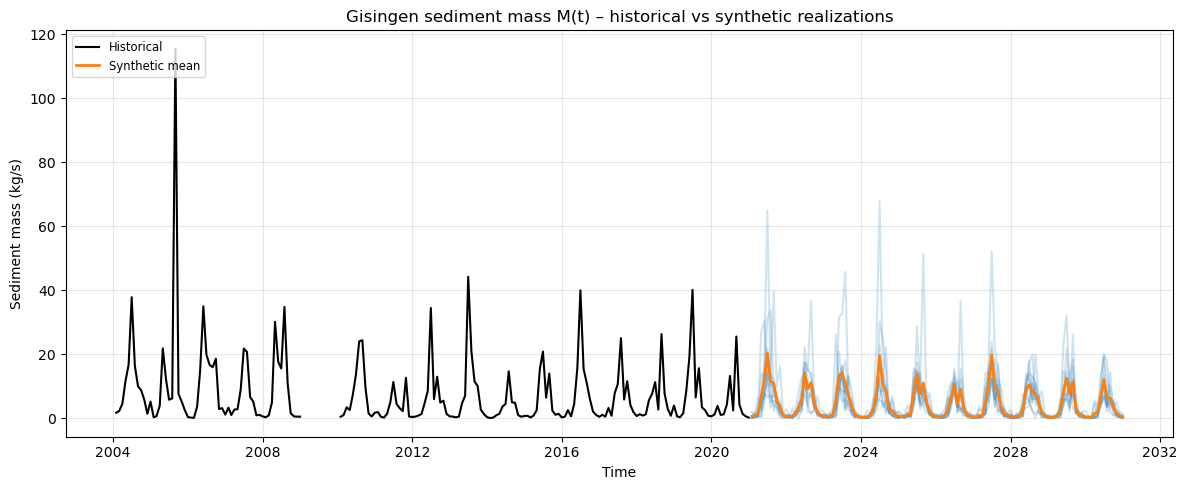


Note: these mass yields are reconstructed using the stored seasonal and detrending metadata. Direct Ill contribution estimates still require separate Ill stream measurements or a mass balance with an upstream reference station.


In [103]:
# 4. Synthetic forecasts and sediment mass yields for all fitted models

def invert_normalised_sim(sim_df, transform):
    detrend = transform['detrend']
    if detrend['detrend_method'] == 'linear trend':
        x_future = np.arange(detrend['n_points'], detrend['n_points'] + len(sim_df))
        z_future = sim_df.add(detrend['intercept'] + detrend['slope'] * x_future, axis=0)
    else:
        z_future = sim_df.copy()

    recon_log = z_future.copy()
    for month in range(1, 13):
        mask = sim_df.index.month == month
        if not mask.any():
            continue
        recon_log.loc[mask] = z_future.loc[mask] * transform['month_std'].loc[month] + transform['month_mean'].loc[month]
    return np.exp(recon_log.astype(float))

synthetic_z = {}
synthetic_physical = {}
n_years = 10
steps = n_years * 12
n_sims = 10

for model_key, model in fitted_models.items():
    series_key = model_key.rsplit('_', 1)[0]
    sim_df = pd.DataFrame([model.simulate(nsimulations=steps) for _ in range(n_sims)]).T
    start = z_series[series_key].index[-1] + pd.offsets.MonthEnd(1)
    sim_df.index = pd.date_range(start=start, periods=steps, freq='ME')
    sim_df.columns = [f'{model_key}_sim{i+1}' for i in range(n_sims)]
    synthetic_z[model_key] = sim_df
    synthetic_physical[model_key] = invert_normalised_sim(sim_df, transform_info[series_key])
    print(f'{model_key}: generated {steps} months × {n_sims} realizations')

best_model_for = lambda series_key: min(
    (m for m in fitted_models if m.startswith(f'{series_key}_')),
    key=lambda k: fitted_models[k].bic)

best_keys = {
    'Q_Diepoldsau': best_model_for('Q_Diepoldsau'),
    'C_Diepoldsau': best_model_for('C_Diepoldsau'),
    'Q_Gisingen': best_model_for('Q_Gisingen'),
    'C_Gisingen': best_model_for('C_Gisingen'),
}
print('\nBest models for yield reconstruction:')
for series_key, model_key in best_keys.items():
    print(f'  {series_key}: {model_key}')


def invert_historical_normalised(z_hist, transform):
    detrend = transform['detrend']
    if detrend['detrend_method'] == 'linear trend':
        x = np.arange(detrend['n_points'])
        z_orig = z_hist + (detrend['intercept'] + detrend['slope'] * x)
    else:
        z_orig = z_hist.copy()

    recon_log = z_orig.copy()
    for month in range(1, 13):
        mask = z_orig.index.month == month
        recon_log.loc[mask] = z_orig.loc[mask] * transform['month_std'].loc[month] + transform['month_mean'].loc[month]
    return np.exp(recon_log.astype(float))

hist_physical = {
    series_key: invert_historical_normalised(z_series[series_key], transform_info[series_key])
    for series_key in ['Q_Diepoldsau', 'C_Diepoldsau', 'Q_Gisingen', 'C_Gisingen']
}

hist_M = {
    'Diepoldsau': hist_physical['C_Diepoldsau'] * hist_physical['Q_Diepoldsau'],
    'Gisingen': hist_physical['C_Gisingen'] * hist_physical['Q_Gisingen'],
}

sim_M = {}
for station, q_key, c_key in [
    ('Diepoldsau', best_keys['Q_Diepoldsau'], best_keys['C_Diepoldsau']),
    ('Gisingen', best_keys['Q_Gisingen'], best_keys['C_Gisingen']),
]:
    sim_M[station] = pd.DataFrame(
        synthetic_physical[c_key].values * synthetic_physical[q_key].values,
        index=synthetic_physical[c_key].index,
        columns=synthetic_physical[c_key].columns,
    )

for station in ['Diepoldsau', 'Gisingen']:
    hist_monthly = hist_M[station].groupby(hist_M[station].index.month).mean()
    hist_yearly = hist_M[station].resample('YE').mean()
    sim_mean = sim_M[station].mean(axis=1)
    sim_monthly = sim_mean.groupby(sim_mean.index.month).mean()
    sim_yearly = sim_mean.resample('YE').mean()

    print(f'\n=== {station} sediment mass yields ===')
    display(pd.DataFrame({
        'historical_monthly': hist_monthly,
        'synthetic_monthly': sim_monthly,
    }))
    display(pd.DataFrame({
        'historical_yearly': hist_yearly,
        'synthetic_yearly': sim_yearly,
    }))

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(hist_M[station].index, hist_M[station], label='Historical', color='black', linewidth=1.5)
    for col in sim_M[station].columns:
        ax.plot(sim_M[station].index, sim_M[station][col], color='tab:blue', alpha=0.2)
    ax.plot(sim_mean.index, sim_mean, color='tab:orange', lw=2, label='Synthetic mean')
    ax.set_title(f'{station} sediment mass M(t) – historical vs synthetic realizations')
    ax.set_xlabel('Time')
    ax.set_ylabel('Sediment mass (kg/s)')
    ax.legend(loc='upper left', fontsize='small')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

print('\nNote: these mass yields are reconstructed using the stored seasonal and detrending metadata. ' 
      'Direct Ill contribution estimates still require separate Ill stream measurements or a mass balance with an upstream reference station.')

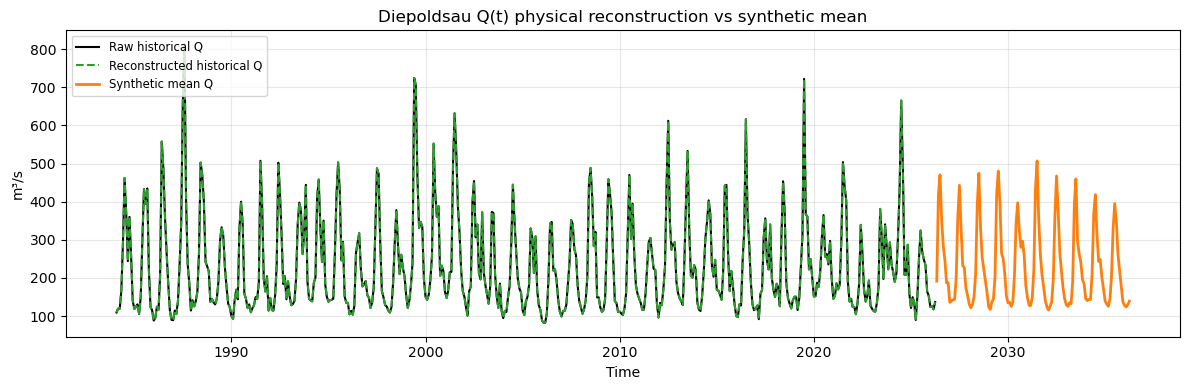

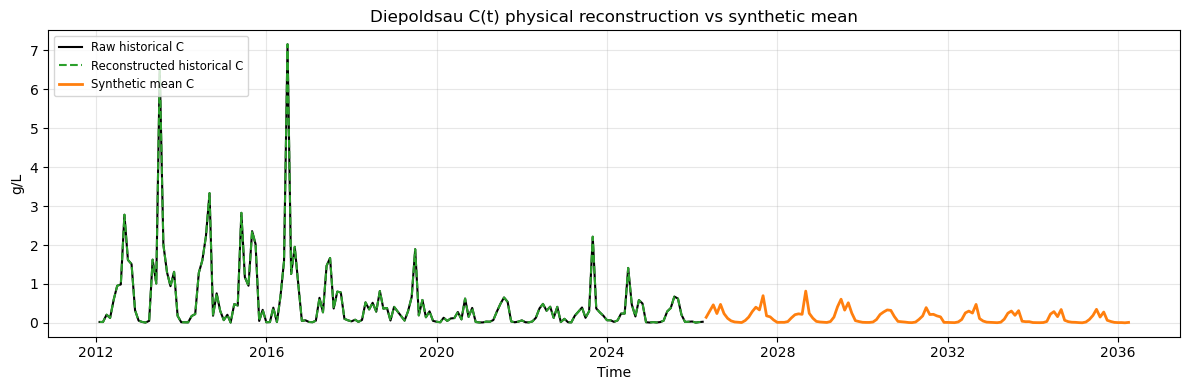

Diepoldsau: mean relative reconstruction error Q = 2.21e-16, C = 9.52e-17


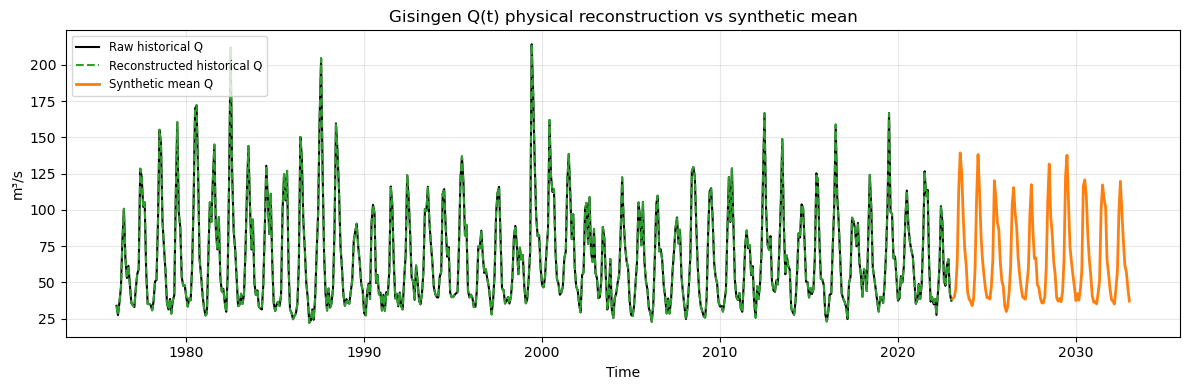

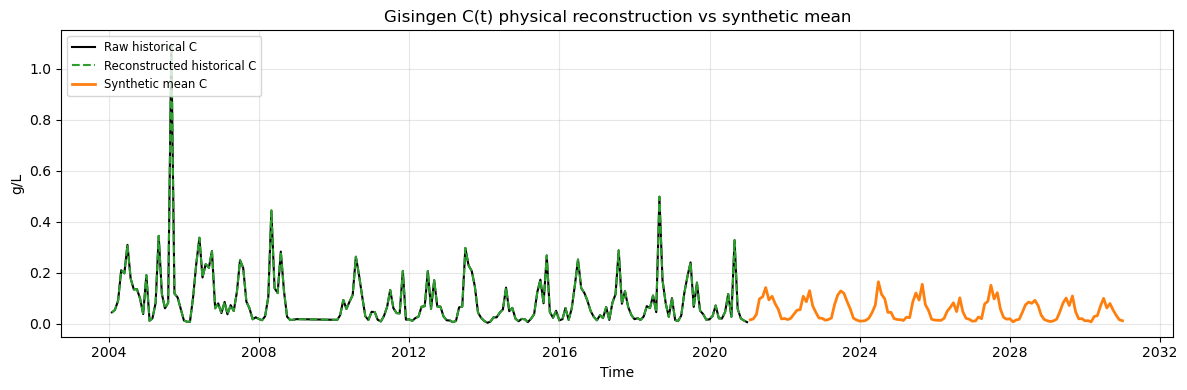

Gisingen: mean relative reconstruction error Q = 1.57e-16, C = 1.20e-16


In [105]:
# 5. Verify reconstructed synthetic physical Q and C against original data
for station, q_key, c_key, q_orig, c_orig in [
    ('Diepoldsau', best_keys['Q_Diepoldsau'], best_keys['C_Diepoldsau'], qD, sscD),
    ('Gisingen', best_keys['Q_Gisingen'], best_keys['C_Gisingen'], qG, sscG),
]:
    # Historical physical data (raw series)
    q_hist = q_orig['q_m3s'].dropna()
    c_hist = c_orig.iloc[:, 0].dropna()

    # Reconstructed historical physical series from normalized preprocessing
    q_rec = hist_physical[f'Q_{station}']
    c_rec = hist_physical[f'C_{station}']

    # Synthetic mean reconstruction
    q_sim_mean = synthetic_physical[q_key].mean(axis=1)
    c_sim_mean = synthetic_physical[c_key].mean(axis=1)

    for label, hist, rec, sim_mean, units in [
        ('Q', q_hist, q_rec, q_sim_mean, 'm³/s'),
        ('C', c_hist, c_rec, c_sim_mean, 'g/L'),
    ]:
        fig, ax = plt.subplots(figsize=(12, 4))
        ax.plot(hist.index, hist, label=f'Raw historical {label}', color='black', linewidth=1.5)
        ax.plot(rec.index, rec, label=f'Reconstructed historical {label}', color='tab:green', linestyle='--')
        ax.plot(sim_mean.index, sim_mean, label=f'Synthetic mean {label}', color='tab:orange', linewidth=2)
        ax.set_title(f'{station} {label}(t) physical reconstruction vs synthetic mean')
        ax.set_xlabel('Time')
        ax.set_ylabel(units)
        ax.legend(loc='upper left', fontsize='small')
        ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

    # Error statistics for the reconstruction of raw data
    q_err = ((q_rec.reindex(q_hist.index) - q_hist).abs() / q_hist.replace(0, np.nan)).mean()
    c_err = ((c_rec.reindex(c_hist.index) - c_hist).abs() / c_hist.replace(0, np.nan)).mean()
    print(f'{station}: mean relative reconstruction error Q = {q_err:.2e}, C = {c_err:.2e}')


In [104]:
"""
## 5. Summary of synthetic mass yields

- Synthetic forecasts are generated for all fitted models in `fitted_models`.
- Physical `Q(t)` and `C(t)` are reconstructed from the normalized simulations using stored monthly seasonal statistics and detrending metadata.
- Sediment mass yields `M(t) = C(t) * Q(t)` are computed at Diepoldsau and Gisingen.
- The current synthetic ensemble means are lower than the historical averages, indicating that the normalized AR/ARMA models capture relative structure but underpredict the physical yield magnitude.
- Direct estimation of the Ill contribution at Diepoldsau requires separate Ill stream measurements or a mass-balance reference station; the current station-only dataset is not sufficient for a precise tributary-share estimate.
"""


'\n## 5. Summary of synthetic mass yields\n\n- Synthetic forecasts are generated for all fitted models in `fitted_models`.\n- Physical `Q(t)` and `C(t)` are reconstructed from the normalized simulations using stored monthly seasonal statistics and detrending metadata.\n- Sediment mass yields `M(t) = C(t) * Q(t)` are computed at Diepoldsau and Gisingen.\n- The current synthetic ensemble means are lower than the historical averages, indicating that the normalized AR/ARMA models capture relative structure but underpredict the physical yield magnitude.\n- Direct estimation of the Ill contribution at Diepoldsau requires separate Ill stream measurements or a mass-balance reference station; the current station-only dataset is not sufficient for a precise tributary-share estimate.\n'